# Task 2 - Step 3: Final target evaluation (first and only use of Sketch labels)

Sketch labels are loaded through `shared.pacs.load_target_labels(freeze_manifest)`, which first re-hashes every
checkpoint, config and prediction file listed by notebook 02 and refuses if anything changed. The access is
appended to `data/pacs/target_label_access_log.jsonl`. Nothing computed here feeds back into any setting.

Outputs: the required method-comparison table, target change vs Source-only, per-class target accuracy and its
change, confusion matrices, the classes with the largest gain/loss and their dominant confusions, prediction flips
with example images, and the DAN λ controlled-study table.

In [1]:
# ---- Task 2 common header (identical in every Task 2 notebook) ----
import json, os, sys, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Locate the repository root (the folder containing shared/) and make it importable.
REPO = Path.cwd().resolve()
while not (REPO / "shared" / "pacs.py").exists():
    if REPO.parent == REPO:
        raise RuntimeError("Run this notebook from inside the PA1 repository")
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from shared import pacs, pacs_protocol as proto
from shared.config import load_config

T2 = REPO / "task2"
CFG_DIR = T2 / "configs"
SEED = 6304
# Smoke mode (env TASK2_SMOKE=1): 2 epochs x 5 updates per run, all outputs under _smoke/ folders,
# and notebook 03 uses RANDOM labels instead of loading the real Sketch labels.
SMOKE = os.environ.get("TASK2_SMOKE", "0") == "1"
SUB = "_smoke" if SMOKE else ""
RES = T2 / "results" / SUB
TAB, FIG = RES / "tables", RES / "figures"
DATA_TAB = T2 / "results" / "tables"      # data-preparation tables (same in smoke and real mode)
CKPT = T2 / "checkpoints" / SUB            # git-ignored
CACHE = T2 / "cache" / SUB                 # git-ignored
for p in [TAB, FIG, CKPT, CACHE]:
    p.mkdir(parents=True, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Config names (files in task2/configs). The main comparison uses lambda = 1 for DAN.
# DANN/CDAN with the manual's exact settings were unstable (DANN diverged, CDAN collapsed repeatedly). Two fixes
# were tried, both chosen from source-side evidence only (see task2/RUN_LOG.md):
#   1) discriminator lr x10 (2026-09-22, before target evaluation): CDAN stable, DANN diverged at epoch 10;
#   2) BatchNorm in the discriminator hidden layer, manual lr (post-evaluation rerun after root-cause diagnosis).
# Fix 2 passes the pre-set stability criteria for both and is the main DANN/CDAN row; all other runs are reported.
MAIN_RUNS = ["source_only", "dan", "dann_discbn", "cdan_discbn"]
ADAPT_MAIN = ["dan", "dann_discbn", "cdan_discbn"]
AS_SPECIFIED_ADV = ["dann", "cdan"]
DISCLR10_ADV = ["dann_disclr10", "cdan_disclr10"]
ADV_RUNS = ["dann_discbn", "cdan_discbn", "dann_disclr10", "cdan_disclr10", "dann", "cdan"]
STUDY_RUNS = ["dan_lambda0.1", "dan", "dan_lambda10"]          # DAN lambda in {0.1, 1, 10}
ALL_RUNS = MAIN_RUNS + DISCLR10_ADV + AS_SPECIFIED_ADV + ["dan_lambda0.1", "dan_lambda10"]
RUN_NAME = {c: load_config(CFG_DIR, c)["run_name"] for c in ALL_RUNS}
LABEL = {"source_only": "Source-only", "dan": "DAN (λ=1)", "dann_discbn": "DANN (disc BN)", "cdan_discbn": "CDAN (disc BN)",
         "dann_disclr10": "DANN (disc lr×10)",
         "cdan_disclr10": "CDAN (disc lr×10)", "dann": "DANN (as specified)", "cdan": "CDAN (as specified)",
         "dan_lambda0.1": "DAN (λ=0.1)", "dan_lambda10": "DAN (λ=10)"}

plt.rcParams.update({"font.size": 11, "axes.titlesize": 12, "legend.fontsize": 9, "savefig.dpi": 150})


def savefig(fig, stem):
    """Every figure is saved as PNG + PDF (never only displayed)."""
    fig.savefig(FIG / f"{stem}.png", bbox_inches="tight")
    fig.savefig(FIG / f"{stem}.pdf", bbox_inches="tight")
    print("saved figure", stem)


print("REPO:", REPO, "| device:", DEVICE, "| smoke:", SMOKE)

REPO: C:\Users\afifh\Desktop\ATML\PA1 | device: cuda | smoke: False


In [2]:
from shared.evaluation import cls_metrics, confusion, per_class_accuracy

CLASSES = pacs.class_names()
T_OUT = torch.load(CACHE / "target_outputs.pt", weights_only=False)["runs"]
if SMOKE:
    y_t = np.random.default_rng(0).integers(0, 7, size=len(pacs.load_target_images()))
    print("SMOKE MODE: random stand-in labels - real Sketch labels were NOT loaded")
else:
    y_t = pacs.load_target_labels(CACHE / "freeze_manifest.json").numpy()
PRED = {n: T_OUT[n]["target_logits"].argmax(1).numpy() for n in ALL_RUNS}
SRC = pd.read_csv(TAB / "task2_source_validation.csv").set_index("config")
SEP = pd.read_csv(TAB / "task2_domain_separability.csv").set_index("config")
print("target images:", len(y_t))

target images: 3929


## 3.1 Method comparison (required table)

In [3]:
TGT = {n: cls_metrics(y_t, PRED[n]) for n in ALL_RUNS}
rows = []
for n in ALL_RUNS:
    rows.append({"config": n, "method": LABEL[n],
                 **{c: SRC.loc[n, c] for c in SRC.columns if c.endswith("_acc") or c.endswith("_macro_f1")},
                 "target_acc": TGT[n]["acc"], "target_macro_f1": TGT[n]["macro_f1"],
                 "target_acc_change_vs_source_only": TGT[n]["acc"] - TGT["source_only"]["acc"],
                 "target_macro_f1_change_vs_source_only": TGT[n]["macro_f1"] - TGT["source_only"]["macro_f1"],
                 "source_minus_target_acc": SRC.loc[n, "mean_acc"] - TGT[n]["acc"],
                 "domain_separability": SEP.loc[n, "separability_acc"]})
COMP = pd.DataFrame(rows)
COMP.to_csv(TAB / "task2_method_comparison.csv", index=False)
cols = ["method", "photo_acc", "art_painting_acc", "cartoon_acc", "mean_acc", "mean_macro_f1", "target_acc",
        "target_macro_f1", "target_acc_change_vs_source_only", "domain_separability"]
COMP[COMP.config.isin(MAIN_RUNS)][cols].round(4)

,method,photo_acc,art_painting_acc,cartoon_acc,mean_acc,mean_macro_f1,target_acc,target_macro_f1,target_acc_change_vs_source_only,domain_separability
0,Source-only,0.9551,0.9073,0.9403,0.9342,0.9317,0.6747,0.6718,0.0000,0.9973
1,DAN (λ=1),0.9760,0.8976,0.9574,0.9437,0.9428,0.6989,0.6373,0.0242,0.8516
2,DANN (disc BN),0.9611,0.9341,0.9424,0.9459,0.9443,0.6518,0.6642,-0.0229,1.0000
3,CDAN (disc BN),0.9611,0.9146,0.9403,0.9387,0.9391,0.5185,0.4866,-0.1563,0.9973


## 3.2 Per-class target accuracy and change vs Source-only

In [4]:
PC = {n: per_class_accuracy(y_t, PRED[n], CLASSES) for n in ALL_RUNS}
rows = []
for n in ALL_RUNS:
    for c in CLASSES:
        rows.append({"config": n, "method": LABEL[n], "class": c, "n_target": int((y_t == CLASSES.index(c)).sum()),
                     "target_acc": PC[n][c], "change_vs_source_only": PC[n][c] - PC["source_only"][c]})
CLASS_T = pd.DataFrame(rows)
CLASS_T.to_csv(TAB / "task2_class_analysis.csv", index=False)
CLASS_T.pivot(index="class", columns="method", values="target_acc")[[LABEL[n] for n in ALL_RUNS]].round(3)

method,Source-only,DAN (λ=1),DANN (disc BN),CDAN (disc BN),DANN (disc lr×10),CDAN (disc lr×10),DANN (as specified),CDAN (as specified),DAN (λ=0.1),DAN (λ=10)
class,,,,,,,,,,
dog,0.174,0.477,0.460,0.552,0.460,0.455,0.076,0.959,0.619,0.0
elephant,0.968,0.835,0.576,0.450,0.861,0.761,0.465,0.112,0.815,0.0
giraffe,0.799,0.672,0.420,0.151,0.789,0.705,0.264,0.337,0.628,0.0
guitar,0.903,0.816,0.982,0.821,0.946,0.954,0.855,0.890,0.939,0.0
horse,0.569,0.702,0.803,0.602,0.483,0.924,0.096,0.260,0.613,0.0
house,0.712,1.000,0.938,1.000,1.000,1.000,0.325,1.000,1.000,0.0
person,0.806,0.656,0.856,0.588,0.994,0.944,0.475,0.938,0.756,1.0


saved figure task2_per_class_target_change


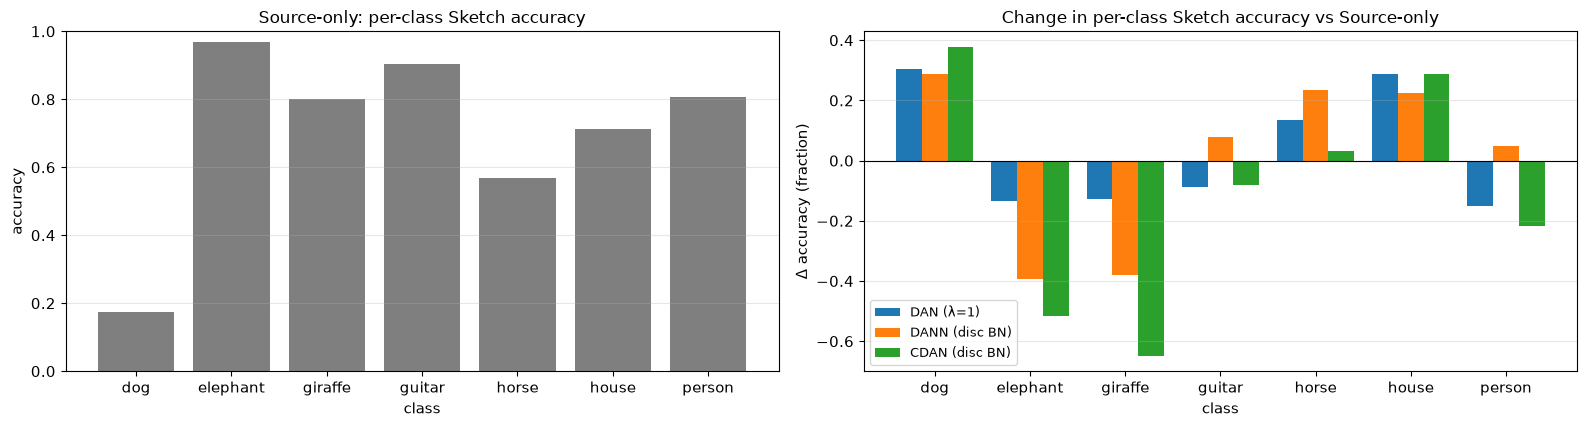

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.4))
x = np.arange(len(CLASSES))
axes[0].bar(x, [PC["source_only"][c] for c in CLASSES], color="tab:gray")
axes[0].set_title("Source-only: per-class Sketch accuracy"); axes[0].set_ylim(0, 1)
w = 0.27
for i, n in enumerate(ADAPT_MAIN):
    axes[1].bar(x + (i - 1) * w, [PC[n][c] - PC["source_only"][c] for c in CLASSES], w, label=LABEL[n])
axes[1].axhline(0, color="k", lw=.8); axes[1].legend()
axes[1].set_title("Change in per-class Sketch accuracy vs Source-only")
for ax, yl in zip(axes, ["accuracy", "Δ accuracy (fraction)"]):
    ax.set_xticks(x); ax.set_xticklabels(CLASSES); ax.set_ylabel(yl); ax.set_xlabel("class"); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); savefig(fig, "task2_per_class_target_change"); plt.show()

## 3.3 Confusions, largest gains / losses and their dominant confusions

saved figure task2_confusions


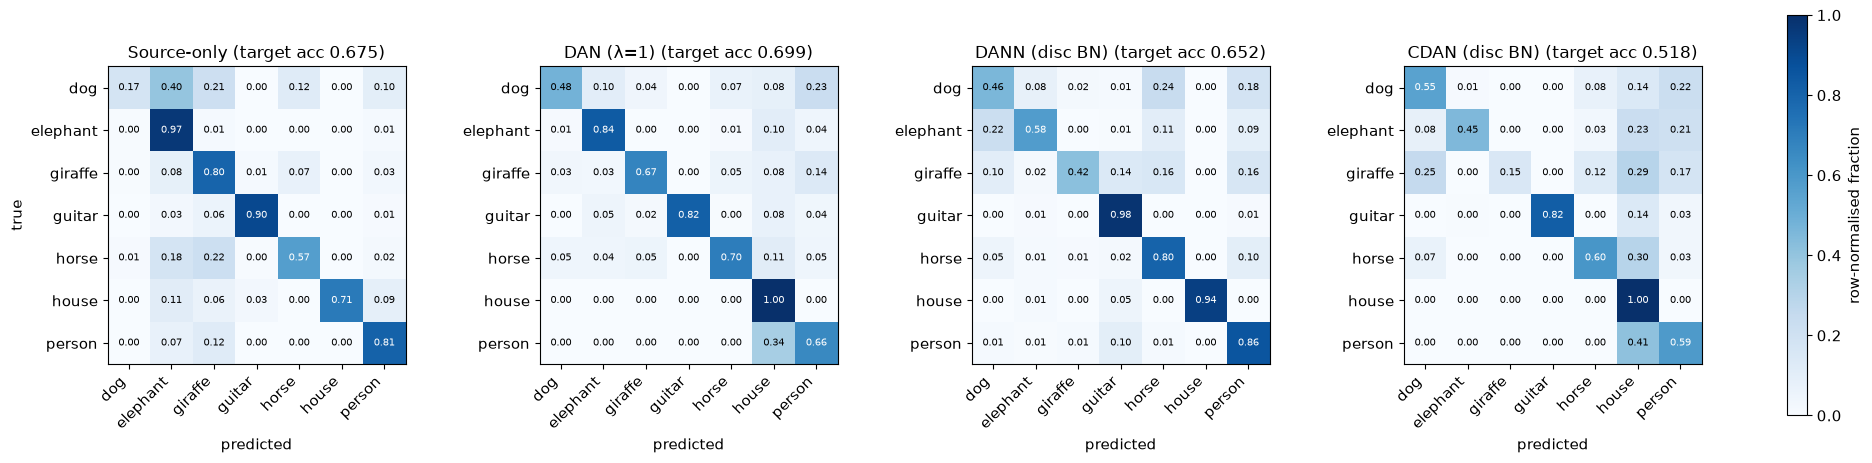

In [6]:
CM = {n: confusion(y_t, PRED[n]) for n in ALL_RUNS}
pd.DataFrame([{"config": n, "true": CLASSES[i], "pred": CLASSES[j], "count": int(CM[n][i, j])}
              for n in ALL_RUNS for i in range(7) for j in range(7)]).to_csv(TAB / "task2_confusions.csv", index=False)

fig, axes = plt.subplots(1, 4, figsize=(22, 5.2), gridspec_kw={"wspace": 0.45})
for ax, n in zip(axes, MAIN_RUNS):
    m = CM[n] / CM[n].sum(1, keepdims=True)
    im = ax.imshow(m, cmap="Blues", vmin=0, vmax=1)
    for i in range(7):
        for j in range(7):
            ax.text(j, i, f"{m[i, j]:.2f}", ha="center", va="center", fontsize=7, color="white" if m[i, j] > .5 else "black")
    ax.set_xticks(range(7)); ax.set_xticklabels(CLASSES, rotation=45, ha="right"); ax.set_yticks(range(7)); ax.set_yticklabels(CLASSES)
    ax.set_title(f"{LABEL[n]} (target acc {TGT[n]['acc']:.3f})"); ax.set_xlabel("predicted")
axes[0].set_ylabel("true")
fig.colorbar(im, ax=axes, fraction=.015, label="row-normalised fraction")
savefig(fig, "task2_confusions"); plt.show()

In [7]:
def dominant_confusion(n, cls):
    i = CLASSES.index(cls)
    row = CM[n][i].copy(); row[i] = 0
    j = int(row.argmax())
    return CLASSES[j], int(row[j]), int(CM[n][i].sum())

rows = []
for n in [r for r in ALL_RUNS if r != "source_only"]:
    delta = {c: PC[n][c] - PC["source_only"][c] for c in CLASSES}
    for kind, c in [("largest_improvement", max(delta, key=delta.get)), ("largest_degradation", min(delta, key=delta.get))]:
        so_c, so_k, tot = dominant_confusion("source_only", c)
        m_c, m_k, _ = dominant_confusion(n, c)
        rows.append({"config": n, "method": LABEL[n], "kind": kind, "class": c, "n_class": tot,
                     "source_only_acc": PC["source_only"][c], "method_acc": PC[n][c], "change": delta[c],
                     "source_only_top_confusion": f"{so_c} ({so_k})", "method_top_confusion": f"{m_c} ({m_k})"})
CASES = pd.DataFrame(rows)
CASES.to_csv(TAB / "task2_transfer_cases.csv", index=False)
CASES.round(3)

,config,method,kind,class,n_class,source_only_acc,method_acc,change,source_only_top_confusion,method_top_confusion
0,dan,DAN (λ=1),largest_improvement,dog,772,0.174,0.477,0.303,elephant (305),person (176)
1,dan,DAN (λ=1),largest_degradation,person,160,0.806,0.656,-0.150,giraffe (19),house (55)
2,dann_discbn,DANN (disc BN),largest_improvement,dog,772,0.174,0.460,0.286,elephant (305),horse (184)
3,dann_discbn,DANN (disc BN),largest_degradation,elephant,740,0.968,0.576,-0.392,giraffe (10),dog (162)
4,cdan_discbn,CDAN (disc BN),largest_improvement,dog,772,0.174,0.552,0.378,elephant (305),person (171)
5,cdan_discbn,CDAN (disc BN),largest_degradation,giraffe,753,0.799,0.151,-0.648,elephant (62),house (222)
6,dann_disclr10,DANN (disc lr×10),largest_improvement,house,80,0.712,1.000,0.288,elephant (9),dog (0)
7,dann_disclr10,DANN (disc lr×10),largest_degradation,elephant,740,0.968,0.861,-0.107,giraffe (10),person (54)
8,cdan_disclr10,CDAN (disc lr×10),largest_improvement,horse,816,0.569,0.924,0.355,giraffe (176),house (26)
9,cdan_disclr10,CDAN (disc lr×10),largest_degradation,elephant,740,0.968,0.761,-0.207,giraffe (10),horse (104)


## 3.4 Prediction flips vs Source-only and example failures

*Negative flip*: Source-only correct, method wrong. *Positive flip*: Source-only wrong, method correct.
Examples are the first images (by Sketch index) of each kind; nothing is selected by score.

In [8]:
so_ok = PRED["source_only"] == y_t
rows = []
for n in [r for r in ALL_RUNS if r != "source_only"]:
    m_ok = PRED[n] == y_t
    rows.append({"config": n, "method": LABEL[n], "positive_flips": int((~so_ok & m_ok).sum()),
                 "negative_flips": int((so_ok & ~m_ok).sum()), "both_correct": int((so_ok & m_ok).sum()),
                 "both_wrong": int((~so_ok & ~m_ok).sum()), "net_change": int(m_ok.sum() - so_ok.sum())})
FLIPS = pd.DataFrame(rows)
FLIPS.to_csv(TAB / "task2_prediction_flips.csv", index=False)
FLIPS

,config,method,positive_flips,negative_flips,both_correct,both_wrong,net_change
0,dan,DAN (λ=1),609,514,2137,669,95
1,dann_discbn,DANN (disc BN),545,635,2016,733,-90
2,cdan_discbn,CDAN (disc BN),526,1140,1511,752,-614
3,dann_disclr10,DANN (disc lr×10),490,347,2304,788,143
4,cdan_disclr10,CDAN (disc lr×10),672,313,2338,606,359
5,dann,DANN (as specified),143,1492,1159,1135,-1349
6,cdan,CDAN (as specified),746,1337,1314,532,-591
7,dan_lambda0.1,DAN (λ=0.1),570,395,2256,708,175
8,dan_lambda10,DAN (λ=10),31,2522,129,1247,-2491


saved figure task2_failure_cases


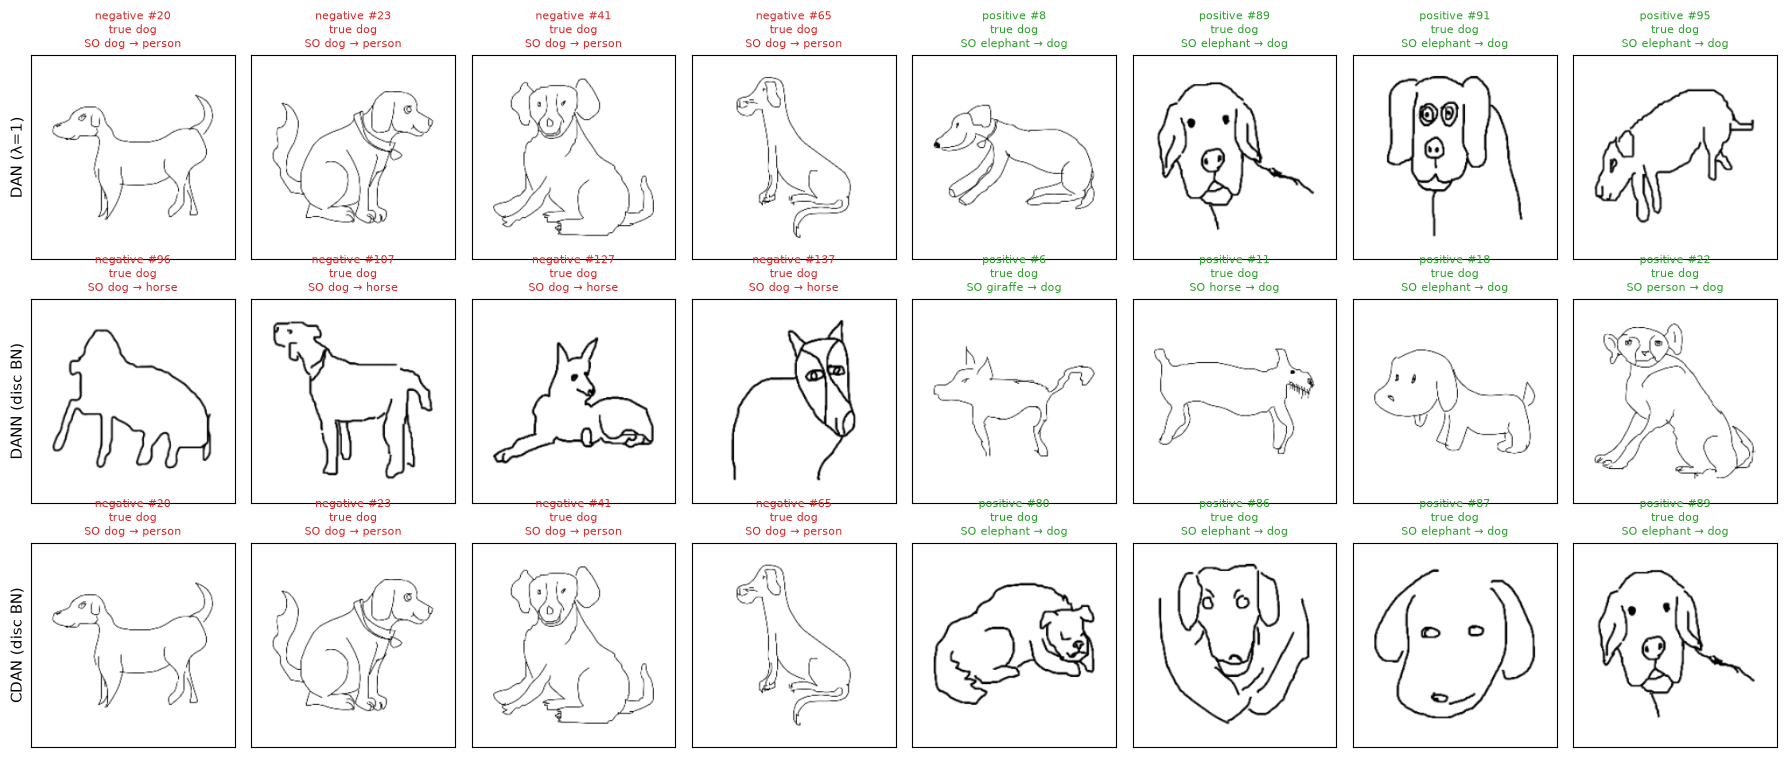

In [9]:
target_images = pacs.load_target_images()
fig, axes = plt.subplots(3, 8, figsize=(18, 7.6))
ex_rows = []
for r, n in enumerate(ADAPT_MAIN):
    neg = np.flatnonzero(so_ok & (PRED[n] != y_t))[:4]
    pos = np.flatnonzero(~so_ok & (PRED[n] == y_t))[:4]
    for c, (i, kind) in enumerate([(i, "negative") for i in neg] + [(i, "positive") for i in pos]):
        ax = axes[r, c]
        ax.imshow(target_images[i].permute(1, 2, 0).numpy()); ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"{kind} #{i}\ntrue {CLASSES[y_t[i]]}\nSO {CLASSES[PRED['source_only'][i]]} → {CLASSES[PRED[n][i]]}",
                     fontsize=8, color="tab:red" if kind == "negative" else "tab:green")
        ex_rows.append({"config": n, "kind": kind, "sketch_index": int(i), "true": CLASSES[y_t[i]],
                        "source_only_pred": CLASSES[PRED["source_only"][i]], "method_pred": CLASSES[PRED[n][i]]})
    axes[r, 0].set_ylabel(LABEL[n], fontsize=11)
pd.DataFrame(ex_rows).to_csv(TAB / "task2_failure_examples.csv", index=False)
plt.tight_layout(); savefig(fig, "task2_failure_cases"); plt.show()

## 3.5 Controlled study: DAN λ ∈ {0.1, 1, 10}

`best_mean_source_val_f1` marks the λ that source validation alone would have chosen (no target labels); it is a
record for RQ4, not a selection that changes any result.

saved figure task2_controlled_study


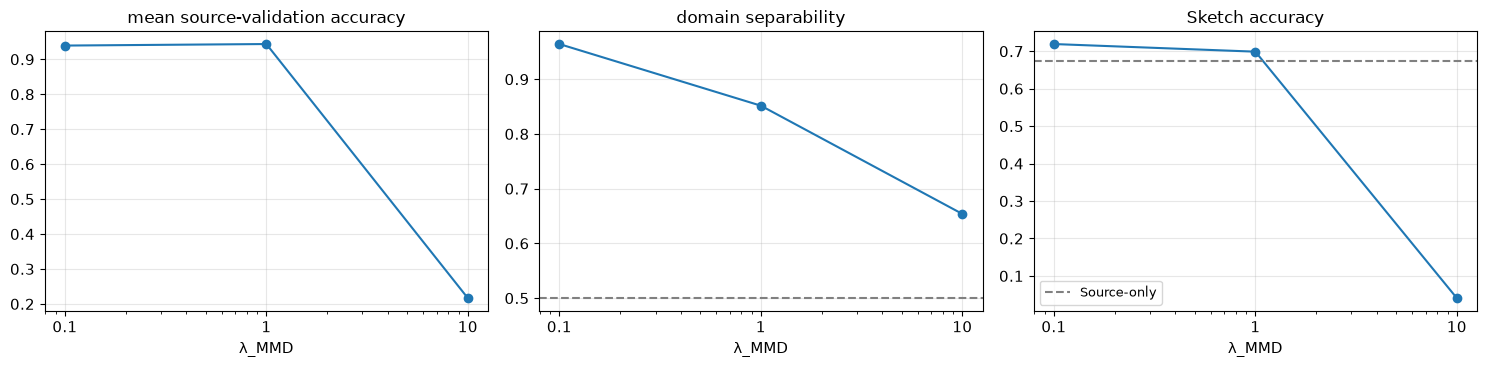

,lambda_mmd,mean_acc,mean_macro_f1,worst_acc,domain_separability,target_acc,target_macro_f1,target_acc_change_vs_source_only,best_mean_source_val_f1
8,0.1,0.9393,0.9398,0.8951,0.9643,0.7193,0.6632,0.0445,False
1,1.0,0.9437,0.9428,0.8976,0.8516,0.6989,0.6373,0.0242,True
9,10.0,0.2166,0.0507,0.1727,0.6538,0.0407,0.0112,-0.6340,False


In [10]:
lam = {"dan_lambda0.1": 0.1, "dan": 1.0, "dan_lambda10": 10.0}
ST = COMP[COMP.config.isin(STUDY_RUNS)].assign(lambda_mmd=lambda d: d.config.map(lam)).sort_values("lambda_mmd")
ST["best_mean_source_val_f1"] = ST.mean_macro_f1 == ST.mean_macro_f1.max()
ST = ST[["lambda_mmd", "mean_acc", "mean_macro_f1", "worst_acc", "domain_separability", "target_acc", "target_macro_f1",
         "target_acc_change_vs_source_only", "best_mean_source_val_f1"]]
ST.to_csv(TAB / "task2_controlled_study.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, col, t in [(axes[0], "mean_acc", "mean source-validation accuracy"), (axes[1], "domain_separability", "domain separability"),
                   (axes[2], "target_acc", "Sketch accuracy")]:
    ax.plot(ST.lambda_mmd, ST[col], marker="o")
    ax.set_xscale("log"); ax.set_xticks([0.1, 1, 10]); ax.set_xticklabels(["0.1", "1", "10"])
    ax.set_xlabel("λ_MMD"); ax.set_title(t); ax.grid(alpha=.3)
axes[1].axhline(0.5, color="gray", ls="--")
axes[2].axhline(TGT["source_only"]["acc"], color="gray", ls="--", label="Source-only"); axes[2].legend()
plt.tight_layout(); savefig(fig, "task2_controlled_study"); plt.show()
ST.round(4)